# 1. Configuration and Imports

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# 2. Load & Prepare Data
Loading the error report from the latest trained version.

In [10]:
# Get info about latest saved version
with open('../latest_version.txt', 'r') as f:
    VERSION = f.read().strip()

BASE_DIR = Path(f'../reports/{VERSION}')

df_err = pd.read_csv(BASE_DIR / 'classification_errors.csv')

def get_source_name(file_path: str) -> str:
    """
    Extracts the original filename from a segmented audio file path.
    Example: 'path/to/yell.wav_seg12.wav' -> 'yell.wav'
    """
    base_name = Path(file_path).name
    source_name = base_name.split('_seg')[0]

    return source_name

# 3. Error Aggregation by Source File
Identifying which original files generate the most errors.

In [11]:
# Create new column
df_err['source_file'] = df_err['file_path'].apply(get_source_name)

# Aggregation: count number of errors
err_report = df_err.groupby('source_file').agg(
    err_nb=('source_file', 'count'),
    true_label=('true_label', 'first'),
    predicted_label=('predicted_label', lambda x: ", ".join(x.unique()))
).sort_values(by='err_nb', ascending=False)

# Write to csv
err_report.to_csv(BASE_DIR / 'error_source_report.csv', index=True)

# Display
print("Top 10 recordings with most errors:")
display(err_report.head(10))

Top 10 recordings with most errors:


,err_nb,true_label,predicted_label
source_file,,,
yell3.wav,30,Violence,Speech
yell_test.wav,26,Violence,"Speech, Ambient"
yell&aggression.wav,13,Violence,Speech
dishwasher.wav,12,Ambient,Speech
yell1.wav,12,Violence,Speech
talk4.wav,10,Speech,"Violence, Ambient"
yell&argument.wav,7,Violence,"Ambient, Speech"
argument2.wav,6,Violence,Speech
yell7.wav,6,Violence,Speech


# 4. Visualization
Visualizing the top 10 problematic recordings.

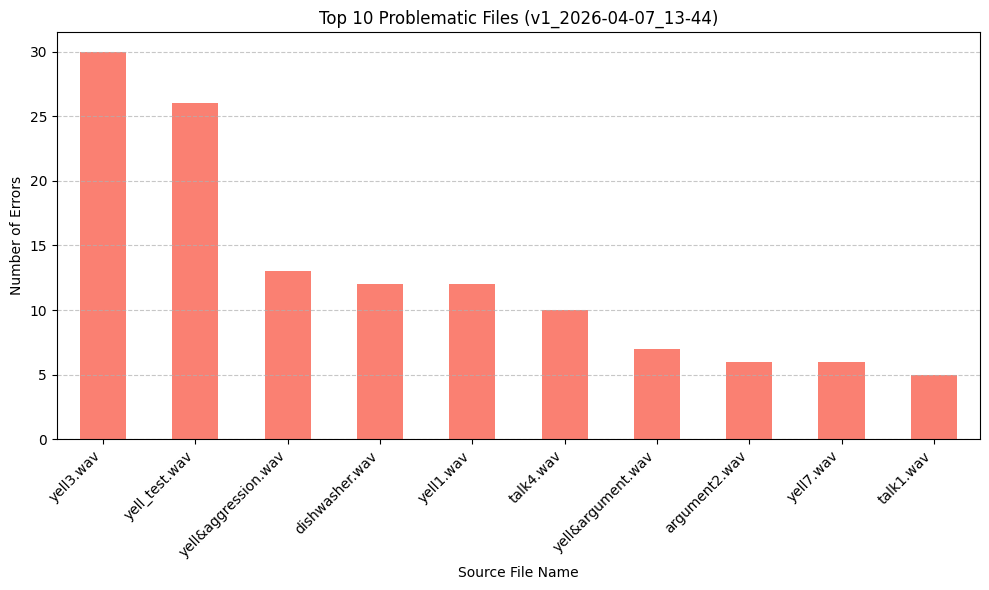

In [12]:
plt.figure(figsize=(10,6))
err_report['err_nb'].head(10).plot(kind='bar', color='salmon')

plt.title(f"Top 10 Problematic Files ({VERSION})")
plt.ylabel("Number of Errors")
plt.xlabel("Source File Name")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save chart
plt.tight_layout() # Ensures all labels are fully visible and not clipped
plt.savefig(BASE_DIR / 'top_errors_chart.png')

plt.show()